In [1]:
%matplotlib inline
import os
import random
import math
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from glob import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils import spectral_norm
from torchvision.utils import make_grid, save_image

manualSeed = 33
random.seed(manualSeed)
np.random.seed(manualSeed)
torch.manual_seed(manualSeed)
torch.backends.cudnn.benchmark = True

FRAMES_ROOT = "/kaggle/input/proyecto-final/frames"
SAMPLE_DIR = "samples"
os.makedirs(SAMPLE_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_gpus = torch.cuda.device_count()
IMAGE_SIZE = 128
BATCH_SIZE_PER_GPU = 32
BATCH_SIZE = max(1, BATCH_SIZE_PER_GPU * max(1, n_gpus))
EPOCHS = 100
LR = 2e-4
BETA1 = 0.5
LAMBDA_L1 = 100.0
SAMPLE_INTERVAL = 1
NUM_WORKERS = min(8, max(1, (os.cpu_count() or 4)//2))
PRINT_FREQ = 20

In [2]:
def resize_and_pad(img, size=(IMAGE_SIZE, IMAGE_SIZE), pad_value=127):
    target_h, target_w = size
    h, w = img.shape[:2]
    scale = min(target_w / w, target_h / h)
    nw, nh = max(1, int(w * scale)), max(1, int(h * scale))
    resized = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_AREA)
    pad_w = target_w - nw
    pad_h = target_h - nh
    top = pad_h // 2
    bottom = pad_h - top
    left = pad_w // 2
    right = pad_w - left
    padded = cv2.copyMakeBorder(resized, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[pad_value, pad_value, pad_value])
    return padded

def load_frames_from_folder(folder):
    files = sorted([os.path.join(folder, f) for f in os.listdir(folder) if not f.startswith('.')])
    frames = []
    for f in files:
        img = cv2.imread(f)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        frames.append(img)
    return frames

def preprocess_to_np(img, image_size=IMAGE_SIZE):
    im = resize_and_pad(img, size=(image_size, image_size))
    arr = im.astype(np.float32)
    arr = (arr - 127.5) / 127.5
    return arr

def build_training_triplets_from_frames_all(frames_all, image_size=IMAGE_SIZE):
    A_list, B_list, MID_list = [], [], []
    for frames in frames_all:
        N = len(frames)
        if N < 3:
            continue
        for i in range(N-2):
            a = preprocess_to_np(frames[i], image_size)
            mid = preprocess_to_np(frames[i+1], image_size)
            b = preprocess_to_np(frames[i+2], image_size)
            A_list.append(a)
            MID_list.append(mid)
            B_list.append(b)
    if len(A_list) == 0:
        return None, None, None
    A = np.array(A_list, dtype=np.float32)
    B = np.array(B_list, dtype=np.float32)
    MID = np.array(MID_list, dtype=np.float32)
    A = A.transpose(0,3,1,2)
    B = B.transpose(0,3,1,2)
    MID = MID.transpose(0,3,1,2)
    return A, B, MID

folders = [os.path.join(FRAMES_ROOT, f"video{i}") for i in range(3)]
frames_all = []
for folder in folders:
    frames = load_frames_from_folder(folder)
    frames_all.append(frames)

A_np, B_np, MID_np = build_training_triplets_from_frames_all(frames_all)
if A_np is None:
    raise RuntimeError("No triplets found. Check FRAMES_ROOT and folder structure.")

X_inputs = np.concatenate([A_np, B_np], axis=1)
dataset = TensorDataset(torch.from_numpy(X_inputs), torch.from_numpy(MID_np))
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)

In [3]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1 or classname.find('Linear') != -1:
        try:
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        except Exception:
            pass
    elif classname.find('BatchNorm') != -1:
        try:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
            nn.init.constant_(m.bias.data, 0)
        except Exception:
            pass

def conv_block(in_c, out_c, k=4, s=2, p=1, act=True):
    layers = [spectral_norm(nn.Conv2d(in_c, out_c, k, s, p, bias=False)), nn.BatchNorm2d(out_c)]
    if act:
        layers.append(nn.LeakyReLU(0.2, inplace=True))
    return nn.Sequential(*layers)

def up_block(in_c, out_c):
    return nn.Sequential(
        nn.Upsample(scale_factor=2, mode='nearest'),
        spectral_norm(nn.Conv2d(in_c, out_c, 3, 1, 1, bias=False)),
        nn.BatchNorm2d(out_c),
        nn.ReLU(inplace=True)
    )

class CondGeneratorUNet(nn.Module):
    def __init__(self, in_channels=6, out_channels=3, ngf=32):
        super().__init__()
        self.e1 = conv_block(in_channels, ngf, k=4, s=2, p=1)
        self.e2 = conv_block(ngf, ngf*2)
        self.e3 = conv_block(ngf*2, ngf*4)
        self.e4 = conv_block(ngf*4, ngf*8)
        self.b = nn.Sequential(
            spectral_norm(nn.Conv2d(ngf*8, ngf*8, 3, 1, 1, bias=False)),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(inplace=True)
        )
        self.u4 = up_block(ngf*8, ngf*4)
        self.u3 = up_block(ngf*8, ngf*2)
        self.u2 = up_block(ngf*4, ngf)
        self.u1 = up_block(ngf*2, ngf)
        self.final = nn.Sequential(spectral_norm(nn.Conv2d(ngf, out_channels, 3, 1, 1, bias=False)), nn.Tanh())
        self.apply(weights_init)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(e1)
        e3 = self.e3(e2)
        e4 = self.e4(e3)
        b  = self.b(e4)
        u4 = self.u4(b)
        u4 = torch.cat([u4, e3], dim=1)
        u3 = self.u3(u4)
        u3 = torch.cat([u3, e2], dim=1)
        u2 = self.u2(u3)
        u2 = torch.cat([u2, e1], dim=1)
        u1 = self.u1(u2)
        out = self.final(u1)
        return out

class CondDiscriminator(nn.Module):
    def __init__(self, in_channels=9, ndf=32):
        super().__init__()
        self.net = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels, ndf, 4, 2, 1, bias=False)), nn.LeakyReLU(0.2, True),
            spectral_norm(nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False)), nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, True),
            spectral_norm(nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False)), nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, True),
            spectral_norm(nn.Conv2d(ndf*4, ndf*8, 4, 1, 1, bias=False)), nn.BatchNorm2d(ndf*8), nn.LeakyReLU(0.2, True),
            spectral_norm(nn.Conv2d(ndf*8, 1, 4, 1, 0, bias=False))
        )
        self.apply(weights_init)

    def forward(self, cond_AB, mid):
        x = torch.cat([cond_AB, mid], dim=1)
        return self.net(x)

G = CondGeneratorUNet(in_channels=6, out_channels=3, ngf=32).to(device)
D = CondDiscriminator(in_channels=9, ndf=32).to(device)

Start training...


/tmp/ipykernel_48/3423125372.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scalerG = torch.cuda.amp.GradScaler()
/tmp/ipykernel_48/3423125372.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scalerD = torch.cuda.amp.GradScaler()
/tmp/ipykernel_48/3423125372.py:110: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_48/3423125372.py:125: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [0/100] Batch [0/48]  D_loss: 0.7071  G_loss: 56.8103  L1: 0.5590
Epoch [0/100] Batch [20/48]  D_loss: 0.6204  G_loss: 11.2636  L1: 0.1035
Epoch [0/100] Batch [40/48]  D_loss: 0.5005  G_loss: 8.1308  L1: 0.0709
==> Época 0/100 | D_loss: 0.5600 | G_loss: 19.1962


/usr/local/lib/python3.11/dist-packages/torch/nn/utils/spectral_norm.py:111: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  sigma = torch.dot(u, torch.mv(weight_mat, v))


Epoch [1/100] Batch [0/48]  D_loss: 0.5045  G_loss: 8.6262  L1: 0.0739
Epoch [1/100] Batch [20/48]  D_loss: 0.6308  G_loss: 7.3985  L1: 0.0623
Epoch [1/100] Batch [40/48]  D_loss: 0.5334  G_loss: 8.0601  L1: 0.0683
==> Época 1/100 | D_loss: 0.5010 | G_loss: 8.3855
Epoch [2/100] Batch [0/48]  D_loss: 0.5377  G_loss: 7.1659  L1: 0.0618
Epoch [2/100] Batch [20/48]  D_loss: 0.3133  G_loss: 8.1147  L1: 0.0596
Epoch [2/100] Batch [40/48]  D_loss: 0.2867  G_loss: 8.6036  L1: 0.0644
==> Época 2/100 | D_loss: 0.5236 | G_loss: 7.7840
Epoch [3/100] Batch [0/48]  D_loss: 0.7146  G_loss: 7.5688  L1: 0.0665
Epoch [3/100] Batch [20/48]  D_loss: 0.5531  G_loss: 7.7083  L1: 0.0618
Epoch [3/100] Batch [40/48]  D_loss: 0.6709  G_loss: 6.6353  L1: 0.0557
==> Época 3/100 | D_loss: 0.5267 | G_loss: 7.4058
Epoch [4/100] Batch [0/48]  D_loss: 0.7424  G_loss: 6.9555  L1: 0.0594
Epoch [4/100] Batch [20/48]  D_loss: 0.3309  G_loss: 8.5640  L1: 0.0661
Epoch [4/100] Batch [40/48]  D_loss: 0.4264  G_loss: 8.5617  L

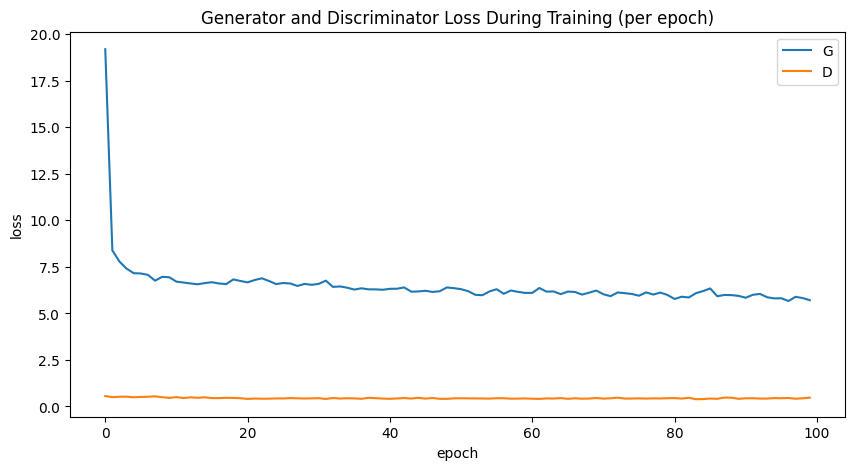

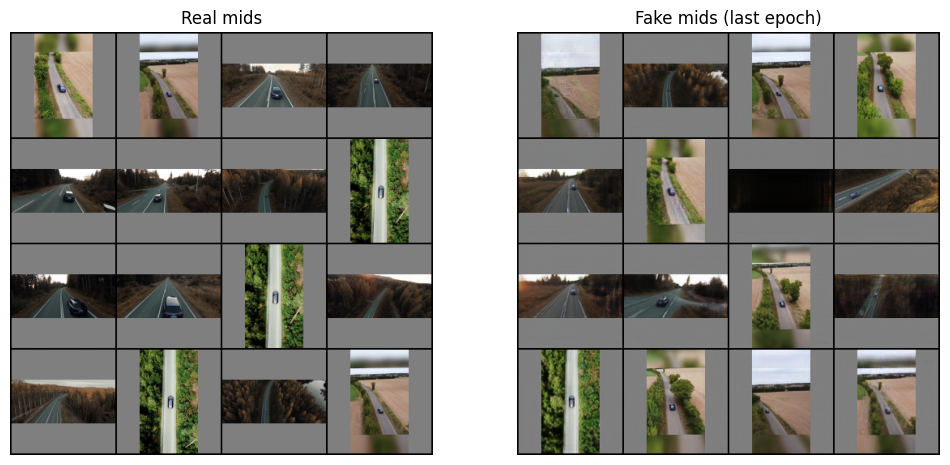

Entrenamiento finalizado. Imágenes guardadas en: samples
/kaggle/input/proyecto-final/frames/video1/frame200.png
/kaggle/input/proyecto-final/frames/video1/frame42.png
/kaggle/input/proyecto-final/frames/video1/frame11.png
/kaggle/input/proyecto-final/frames/video1/frame146.png
/kaggle/input/proyecto-final/frames/video1/frame199.png
/kaggle/input/proyecto-final/frames/video1/frame63.png
/kaggle/input/proyecto-final/frames/video1/frame169.png
/kaggle/input/proyecto-final/frames/video1/frame3.png
/kaggle/input/proyecto-final/frames/video1/frame208.png
/kaggle/input/proyecto-final/frames/video1/frame55.png
/kaggle/input/proyecto-final/frames/video1/frame173.png
/kaggle/input/proyecto-final/frames/video1/frame188.png
/kaggle/input/proyecto-final/frames/video1/frame61.png
/kaggle/input/proyecto-final/frames/video1/frame111.png
/kaggle/input/proyecto-final/frames/video1/frame108.png
/kaggle/input/proyecto-final/frames/video1/frame202.png
/kaggle/input/proyecto-final/frames/video1/frame95.png

<Figure size 600x600 with 0 Axes>

In [4]:
if n_gpus > 1:
    device_ids = list(range(n_gpus))
    G = nn.DataParallel(G, device_ids=device_ids)
    D = nn.DataParallel(D, device_ids=device_ids)

optimizerG = optim.Adam(G.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizerD = optim.Adam(D.parameters(), lr=LR, betas=(BETA1, 0.999))

adversarial_criterion = nn.BCEWithLogitsLoss().to(device)
l1_criterion = nn.L1Loss().to(device)

real_label = 0.9
fake_label = 0.0

scalerG = torch.cuda.amp.GradScaler()
scalerD = torch.cuda.amp.GradScaler()

G_losses = []
D_losses = []
img_list = []

def get_random_fixed_batch(dataset, n=8):
    n = min(n, len(dataset))
    idxs = torch.randperm(len(dataset))[:n]
    conds = []
    mids = []
    for i in idxs:
        cond, mid = dataset[int(i)]
        conds.append(cond)
        mids.append(mid)
    conds = torch.stack(conds, dim=0).to(device)
    mids = torch.stack(mids, dim=0).to(device)
    return conds, mids

def sample_and_show(cond_AB_batch, real_mid_batch, epoch, n_show=4, show=True):
    G.eval()
    with torch.no_grad():
        cond = cond_AB_batch[:n_show].to(device)
        real_mid = real_mid_batch[:n_show].to(device)
        fake_mid = G(cond)
        cond0 = (cond[:, :3] + 1) / 2.0
        cond1 = (cond[:, 3:] + 1) / 2.0
        fake = (fake_mid + 1) / 2.0
        real = (real_mid + 1) / 2.0
        rows = []
        for i in range(n_show):
            row = torch.cat([cond0[i], fake[i], real[i], cond1[i]], dim=2)
            rows.append(row)
        grid = torch.stack(rows, dim=0)
        grid_img = make_grid(grid, nrow=1)
        out_path = os.path.join(SAMPLE_DIR, f'epoch_{epoch:04d}.png')
        save_image(grid_img, out_path)
        if show:
            np_img = grid_img.cpu().permute(1,2,0).numpy()
            plt.figure(figsize=(12, 3*n_show))
            plt.imshow(np_img)
            plt.axis('off')
            plt.title(f'Epoch {epoch}')
            plt.show()
    G.train()

def get_per_video_batch(frames_all, frame_idx, device=torch.device("cpu"), image_size=IMAGE_SIZE):
    conds = []
    mids = []
    for vid_idx, frames in enumerate(frames_all):
        if frame_idx + 2 < len(frames):
            a = preprocess_to_np(frames[frame_idx], image_size)
            mid = preprocess_to_np(frames[frame_idx+1], image_size)
            b = preprocess_to_np(frames[frame_idx+2], image_size)
            a_t = torch.from_numpy(a.transpose(2,0,1)).float()
            mid_t = torch.from_numpy(mid.transpose(2,0,1)).float()
            b_t = torch.from_numpy(b.transpose(2,0,1)).float()
            cond = torch.cat([a_t, b_t], dim=0)
            conds.append(cond)
            mids.append(mid_t)
    if len(conds) == 0:
        return None, None
    conds = torch.stack(conds, dim=0).to(device)
    mids = torch.stack(mids, dim=0).to(device)
    return conds, mids

def save_per_video_frames(fake_batch, frame_idx, epoch, out_dir="samples"):
    os.makedirs(out_dir, exist_ok=True)
    for vid_idx in range(fake_batch.size(0)):
        vdir = os.path.join(out_dir, f"video_{vid_idx:02d}")
        os.makedirs(vdir, exist_ok=True)
        img = fake_batch[vid_idx].cpu().clamp(0.0,1.0).numpy()
        img = np.transpose(img, (1,2,0))
        path = os.path.join(vdir, f"frame_{frame_idx:06d}.png")
        save_image(torch.from_numpy(img.transpose(2,0,1)), path)

print("Start training...")
for epoch in range(EPOCHS):
    epoch_g_losses = []
    epoch_d_losses = []
    per_video_cond, per_video_mid = get_per_video_batch(frames_all, epoch, device=device)
    if per_video_cond is None:
        fixed_cond, fixed_mid = get_random_fixed_batch(dataset, n=min(16, len(dataset)))
        fixed_cond, fixed_mid = fixed_cond.to(device), fixed_mid.to(device)
        use_per_video = False
    else:
        fixed_cond, fixed_mid = per_video_cond, per_video_mid
        use_per_video = True

    for i, (cond_AB, real_mid) in enumerate(dataloader):
        cond_AB = cond_AB.to(device, non_blocking=True)
        real_mid = real_mid.to(device, non_blocking=True)
        b_size = cond_AB.size(0)
        optimizerD.zero_grad()
        with torch.cuda.amp.autocast():
            fake_mid = G(cond_AB)
            real_logits = D(cond_AB, real_mid)
            fake_logits = D(cond_AB, fake_mid.detach())
            real_scores = real_logits.view(b_size, -1).mean(dim=1)
            fake_scores = fake_logits.view(b_size, -1).mean(dim=1)
            real_labels = torch.full_like(real_scores, real_label, device=device)
            fake_labels = torch.full_like(fake_scores, fake_label, device=device)
            lossD_real = adversarial_criterion(real_scores, real_labels)
            lossD_fake = adversarial_criterion(fake_scores, fake_labels)
            lossD = (lossD_real + lossD_fake) * 0.5
        scalerD.scale(lossD).backward()
        scalerD.step(optimizerD)
        scalerD.update()
        optimizerG.zero_grad()
        with torch.cuda.amp.autocast():
            fake_mid = G(cond_AB)
            fake_logits_for_g = D(cond_AB, fake_mid)
            fake_scores_g = fake_logits_for_g.view(b_size, -1).mean(dim=1)
            target_for_g = torch.full_like(fake_scores_g, real_label, device=device)
            adv_loss = adversarial_criterion(fake_scores_g, target_for_g)
            l1_loss = l1_criterion(fake_mid, real_mid)
            lossG = adv_loss + LAMBDA_L1 * l1_loss
        scalerG.scale(lossG).backward()
        scalerG.step(optimizerG)
        scalerG.update()
        epoch_d_losses.append(lossD.item())
        epoch_g_losses.append(lossG.item())
        if (i % PRINT_FREQ) == 0:
            print(f"Epoch [{epoch}/{EPOCHS}] Batch [{i}/{len(dataloader)}]  D_loss: {lossD.item():.4f}  G_loss: {lossG.item():.4f}  L1: {l1_loss.item():.4f}")

    avg_d = float(np.mean(epoch_d_losses)) if epoch_d_losses else 0.0
    avg_g = float(np.mean(epoch_g_losses)) if epoch_g_losses else 0.0
    D_losses.append(avg_d)
    G_losses.append(avg_g)
    print(f"==> Época {epoch}/{EPOCHS} | D_loss: {avg_d:.4f} | G_loss: {avg_g:.4f}")

    if use_per_video:
        G.eval()
        with torch.no_grad():
            fake = G(fixed_cond)
            fake_vis = (fake + 1.0) / 2.0
            save_per_video_frames(fake_vis, frame_idx=epoch, epoch=epoch, out_dir=SAMPLE_DIR)
            grid = make_grid(fake_vis[:min(4,fake_vis.size(0))], nrow=min(4,fake_vis.size(0)), normalize=False)
            save_image(grid, os.path.join(SAMPLE_DIR, f'epoch_{epoch:04d}_per_video_grid.png'))
        G.train()
    else:
        sample_and_show(fixed_cond, fixed_mid, epoch, n_show=min(4, fixed_cond.size(0)), show=True)
        with torch.no_grad():
            img = make_grid(((G(fixed_cond[:4].to(device)).detach()+1)/2.0), nrow=4, normalize=False)
            img_list.append(img.cpu())

plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training (per epoch)")
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

real_batch = next(iter(dataloader))[1]
with torch.no_grad():
    cond_batch = next(iter(dataloader))[0]
    fake_batch = G(cond_batch.to(device)[:16]).cpu()

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real mids")
plt.imshow(np.transpose(make_grid((real_batch[:16]+1)/2.0, nrow=4).numpy(), (1,2,0)))
plt.subplot(1,2,2)
plt.axis("off")
plt.title("Fake mids (last epoch)")
plt.imshow(np.transpose(make_grid((fake_batch+1)/2.0, nrow=4).numpy(), (1,2,0)))
plt.show()

try:
    import matplotlib.animation as animation
    from IPython.display import HTML
    fig = plt.figure(figsize=(6,6))
    ims = []
    for im in img_list:
        imshow_obj = plt.imshow(np.transpose(im.numpy(), (1,2,0)), animated=True)
        plt.axis('off')
        ims.append([imshow_obj])
    ani = animation.ArtistAnimation(fig, ims, interval=800, repeat_delay=1000, blit=True)
    display(HTML(ani.to_jshtml()))
except Exception:
    pass

print("Entrenamiento finalizado. Imágenes guardadas en:", SAMPLE_DIR)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [6]:
!ffmpeg -y -framerate 12 -i samples/video_00/frame_%06d.png -vf "scale=640:-1:flags=lanczos" /kaggle/working/video_00.gif

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab